# Training

## Konfigurasi Global

In [1]:
IS_USING_FFT_DOMAIN = True
WINDOW_SIZE = 128

ROOT_PROJECT_DATASET = "/home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing"
BEARING_VARIATION_FOLDER = ("bearing_1", )

BEARING_LIFESPAN_TIME = 392_275
TURNING_POINT_TIME = 290000

MAIN_BEARING = BEARING_VARIATION_FOLDER[0] # Pilih bearing utama untuk analisis

# FFT Domain
# 0 - 1280 Hz
FREQUENCY_MIN, FREQUENCY_MAX = 220, 260
SAMPLING_RATE = 2560

In [2]:
'''
HI : BLACK - Full line
TP : RED - Full line
X : BLUE - Full Line 
Y : ORANGE - Full line 
Z : GREEN - Full line
'''

PLOT_STYLES = {
    "HI": {"color": "black", "linestyle": "-"},
    "HI_PRED": {"color": "gold", "linestyle": "--"},
    "TP": {"color": "red", "linestyle": "-"},
    "TP_PRED": {"color": "red", "linestyle": "--"},
    "X": {"color": "blue", "linestyle": "-"},
    "Y": {"color": "orange", "linestyle": "-"},
    "Z": {"color": "green", "linestyle": "-"},
}

colors_map = {
    'RAW Dual': '#1f77b4',
    'RAW Single': '#ff7f0e',
    'FFT Dual': '#2ca02c',
    'FFT Single': '#d62728'
}

## Import

In [3]:
import os
import glob
import re
import time

import numpy as np
from numpy.fft import rfft, rfftfreq

import pandas as pd

import dask.dataframe as dd
import dask.array as da
from dask.diagnostics.progress import ProgressBar

import torch
import torch.optim as optim
import torch.nn as nn

from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

import plotly.graph_objs as go
import plotly.offline as pyo

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

import seaborn as sns

from tqdm import tqdm  # Import tqdm for progress bar

import gc

## Helper Function

In [4]:
def temp_output_bearing_root(bearing_name: str) -> str:
    return f"{ROOT_PROJECT_DATASET}/{bearing_name}"

def bearing_file_full_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_full.parquet"

def bearing_file_raw_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_raw.parquet"

def export_dataset_root(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/datasets"

def export_dataset_name_for_fft_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/fft"

def export_dataset_name_for_raw_base(bearing_name: str) -> str:
    return f"{export_dataset_root(bearing_name)}/raw"


def bearing_file_fft_parquet(bearing_name: str) -> str:
    return f"{temp_output_bearing_root(bearing_name)}/{bearing_name}_fft.parquet"

def series_health_index(t: float, Tcp: float, Tf: float) -> float:
    """Calculate the health index based on time, Tcp, and Tf.
    Args:
        t (float): current time
        Tcp (float): turning point time
        Tf (float): max time

    Returns:
        float: health index value between 0 (Broken) and 1 (Good)
    """
    return 1 - ( max((t - Tcp), 0) / (Tf - Tcp) )

def health_index_to_rul(health_index, Tf: float) -> float:
    """
    Convert health index (HI) to RUL.
    HI: 1.0 = new, 0.0 = failed
    max_rul: maximum RUL (e.g., total life in seconds or cycles)
    """
    return np.clip(health_index, 0, 1) * Tf

def create_sequences(X, y, window_size=10):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X[i:(i + window_size)])
        ys.append(y[i + window_size])
    return np.array(Xs), np.array(ys)

def rmse_score(y_true, y_pred):
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def relative_prediction_error(y_true, y_pred):
    """Relative Prediction Error (RPE) as a percentage"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Avoid division by zero
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def accuracy_score(y_true, y_pred):
    """
    Calculate the accuracy score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Accuracy score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    """
    Calculate the precision score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Precision score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    return true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0.0

def recall_score(y_true, y_pred):
    """
    Calculate the recall score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: Recall score (between 0 and 1).
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))
    return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0.0

def f1_score(y_true, y_pred):
    """
    Calculate the F1 score for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        float: F1 score (between 0 and 1).
    """
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def confusion_matrix(y_true, y_pred):
    """
    Calculate the confusion matrix for binary or multiclass classification.
    Args:
        y_true (array-like): Ground truth labels.
        y_pred (array-like): Predicted labels.
    Returns:
        np.ndarray: Confusion matrix.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    classes = np.unique(np.concatenate((y_true, y_pred)))
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    
    for i, true_label in enumerate(classes):
        for j, pred_label in enumerate(classes):
            matrix[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    
    return matrix

def asymmetric_loss_scoring_function(y_pred, y_true, a=10, b=13):
    """
    Asymmetric loss for regression (PyTorch version).
    Penalizes late predictions more than early ones using an exponential function.
    y = exp(-(y_pred - y_true)/a) - 1, if early (y_pred < y_true)
    y = exp((y_pred - y_true)/b) - 1, if late (y_pred >= y_true)
    """
    diff = y_pred - y_true
    loss = torch.where(
        diff < 0,
        torch.exp(-diff / a) - 1,   # Early prediction (small penalty)
        torch.exp(diff / b) - 1     # Late prediction (large penalty)
    )
    return loss.mean()

## A. Load Dataset

In [5]:
# Load Training Dataset
if not IS_USING_FFT_DOMAIN:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_raw_base(MAIN_BEARING)}_test_data.parquet"
else:
    TRAIN_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_train_data.parquet"
    TEST_DATA_LOC = f"{export_dataset_name_for_fft_base(MAIN_BEARING)}_{FREQUENCY_MIN}_{FREQUENCY_MAX}_test_data.parquet"

TRAIN_DATA = pd.read_parquet(f"{TRAIN_DATA_LOC}")
TEST_DATA = pd.read_parquet(f"{TEST_DATA_LOC}")

print(f"Train (loc: {TRAIN_DATA_LOC}) shape: ({TRAIN_DATA.shape[0]}, {TRAIN_DATA.shape[1]})")
print(f"Test (loc: {TEST_DATA_LOC}) shape: ({TEST_DATA.shape[0]}, {TEST_DATA.shape[1]})")

Train (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_train_data.parquet) shape: (653, 5)
Test (loc: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_220_260_test_data.parquet) shape: (652, 5)


## B. Normalization

In [6]:
FEATURES = ["FFT_X", "FFT_Y", "FFT_Z"] if IS_USING_FFT_DOMAIN else ["X", "Y", "Z"]
TARGET = "health_index"

fft_scaler = MinMaxScaler()

X_train = fft_scaler.fit_transform(TRAIN_DATA[FEATURES])
y_train = TRAIN_DATA[TARGET].values

X_test = fft_scaler.transform(TEST_DATA[FEATURES])
y_test = TEST_DATA[TARGET].values

## C. Create Sequences Windows

In [7]:
X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size=WINDOW_SIZE)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size=WINDOW_SIZE)

print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

X_train_seq shape: (525, 128, 3), y_train_seq shape: (525,)
X_test_seq shape: (524, 128, 3), y_test_seq shape: (524,)


## D. Convert to Tensor

In [8]:
X_train_tensor = torch.from_numpy(X_train_seq).float()
y_train_tensor = torch.from_numpy(y_train_seq).float().view(-1, 1)

X_test_tensor = torch.from_numpy(X_test_seq).float()
y_test_tensor = torch.from_numpy(y_test_seq).float().view(-1, 1)

y_cp_train = (y_train_seq == 1.0).astype(float)
y_cp_train = torch.from_numpy(y_cp_train).float().view(-1, 1)

y_cp_test = (y_test_seq == 1.0).astype(float)
y_cp_test = torch.from_numpy(y_cp_test).float().view(-1, 1)

y_hi_train = (y_train_seq < 1.0).astype(float)
y_hi_train = torch.from_numpy(y_hi_train).float().view(-1, 1)

y_hi_test = (y_test_seq < 1.0).astype(float)
y_hi_test = torch.from_numpy(y_hi_test).float().view(-1, 1)

## E. Plot Data before Training for Visualization

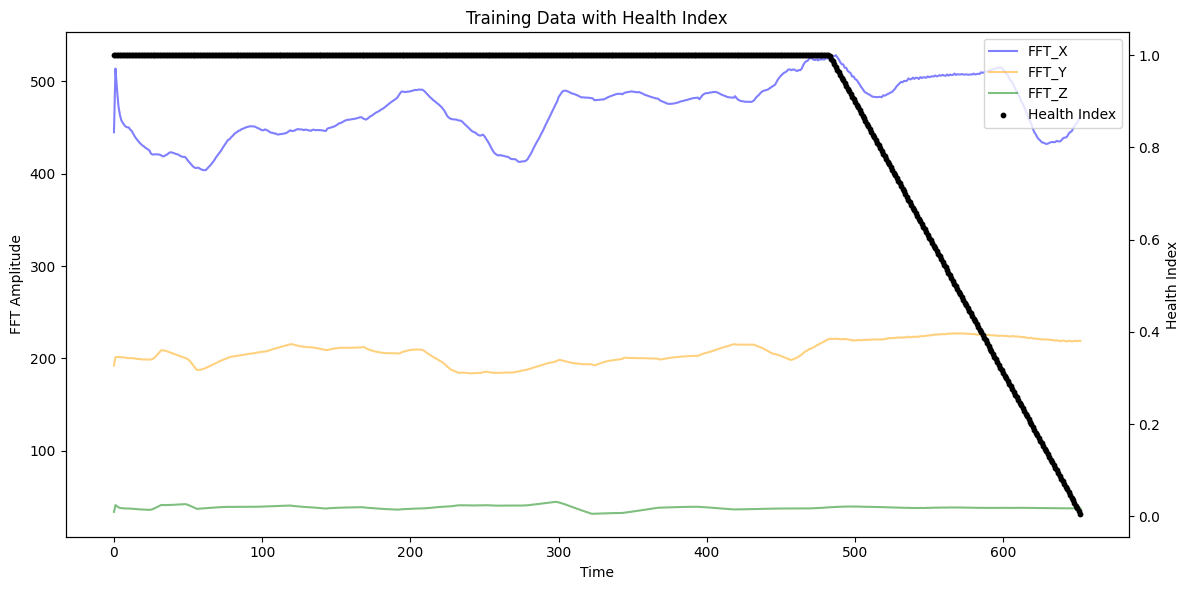

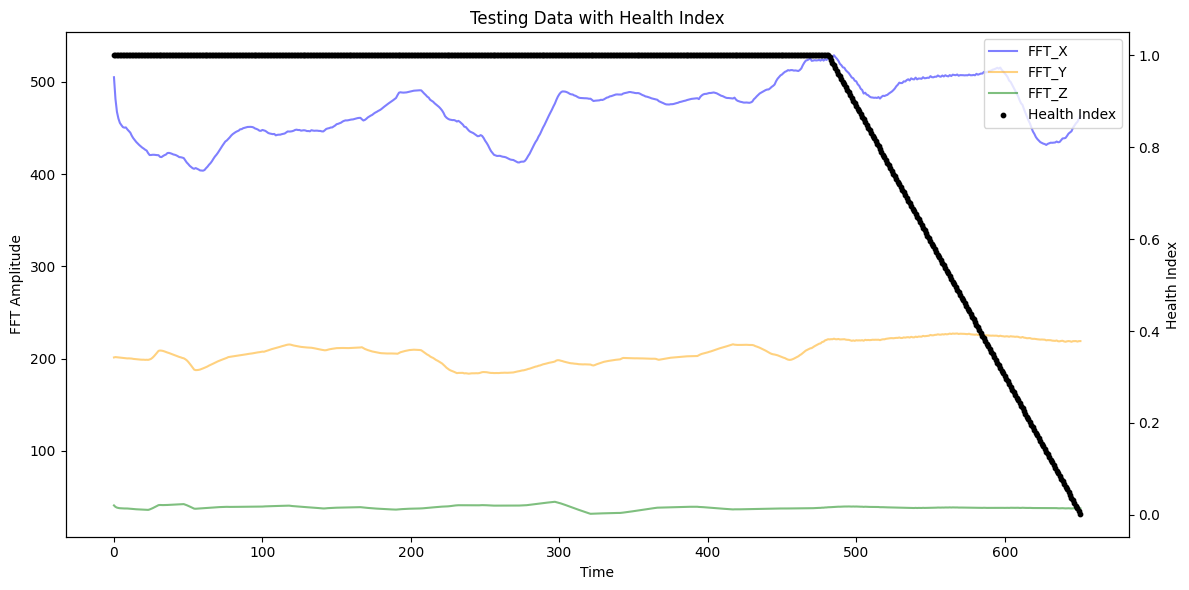

In [9]:
def plot_data_with_health_index(data, title="Data with Health Index"):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    # Plot FFT features on the primary y-axis
    ax1.plot(data.index, data[FEATURES[0]], label=FEATURES[0], alpha=0.5, **PLOT_STYLES["X"])
    ax1.plot(data.index, data[FEATURES[1]], label=FEATURES[1], alpha=0.5, **PLOT_STYLES["Y"])
    ax1.plot(data.index, data[FEATURES[2]], label=FEATURES[2], alpha=0.5, **PLOT_STYLES["Z"])
    ax1.set_xlabel("Time")
    ax1.set_ylabel("FFT Amplitude")
    ax1.legend(loc="upper left")

    # Plot Health Index on the secondary y-axis
    ax2 = ax1.twinx()
    ax2.scatter(data.index, data[TARGET], label='Health Index', s=10, **PLOT_STYLES["HI"])
    ax2.set_ylabel("Health Index", color=PLOT_STYLES["HI"]["color"])
    ax2.tick_params(axis='y', labelcolor=PLOT_STYLES["HI"]["color"])

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_data_with_health_index(TRAIN_DATA, title="Training Data with Health Index")
plot_data_with_health_index(TEST_DATA, title="Testing Data with Health Index")

## F. Define Model

### 1. CPD Model (GRU)

In [10]:
class ChangePointGRU(nn.Module):
    """
    GRU Model 1: Detects the change point from normal operation to degradation.
    This is a binary classification model.
    """
    def __init__(self, input_size=3, hidden_layer_size=50, num_layers=1, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_seq):
        gru_out, _ = self.gru(input_seq)
        last_time_step_out = gru_out[:, -1, :]
        dropped = self.dropout(last_time_step_out)
        linear_out = self.linear(dropped)
        predictions = self.sigmoid(linear_out)
        return predictions

### 2. HI Model (GRU)

In [11]:
class HealthIndexGRU(nn.Module):
    """
    GRU Model 2: Predicts the Health Index (HI) after the change point.
    This is a regression model.
    """
    def __init__(self, input_size=3, hidden_layer_size=50, num_layers=2, output_size=1, dropout_rate=0.2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_layer_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.linear = nn.Linear(hidden_layer_size, output_size)

    def forward(self, input_seq):
        gru_out, _ = self.gru(input_seq)
        last_time_step_out = gru_out[:, -1, :]
        dropped = self.dropout(last_time_step_out)
        predictions = self.linear(dropped)
        return predictions

## G. Training

### 1. Configuration

In [12]:
# Hyperparameters Configuration

EPOCHS = 2000 # Number of epochs for training
PATIENCE = 150 # Early stopping patience

# Change Point Model
CPD_THRESHOLD = 0.85 
CHANGE_POINT_HIDDEN_LAYER_SIZE = 24
CHANGE_POINT_NUM_LAYERS = 1

CHANGE_POINT_DROPOUT_RATE = 0.1
CHANGE_POINT_LEARNING_RATE = 0.002
CHANGE_POINT_BETAS = (0.9, 0.999)  # Adam optimizer parameters, Only edit the second value
CHANGE_POINT_EPSILON = 1e-8  # Adam optimizer epsilon

# Health Index Model
HEALTH_INDEX_HIDDEN_LAYER_SIZE = 26
HEALTH_INDEX_NUM_LAYERS = 2

HEALTH_INDEX_DROPOUT_RATE = 0.1
HEALTH_INDEX_LEARNING_RATE = 0.001
HEALTH_INDEX_BETAS = (0.9, 0.999)  # Adam optimizer parameters, Only edit the second value
HEALTH_INDEX_EPSILON = 1e-8  # Adam optimizer epsilon

# Training strategy parameters
USE_DYNAMIC_CPD = True  # Set to False to use only ground truth
WARMUP_EPOCHS = 0  # Use ground truth for first N epochs
TRANSITION_EPOCHS = 0  # Gradual transition period
CPD_CONFIDENCE_THRESHOLD = 0.7  # Minimum confidence to use CPD prediction


_func = export_dataset_name_for_fft_base if IS_USING_FFT_DOMAIN else export_dataset_name_for_raw_base

### 2. Training

In [13]:
cp_model = ChangePointGRU(input_size=3, hidden_layer_size=CHANGE_POINT_HIDDEN_LAYER_SIZE, num_layers=CHANGE_POINT_NUM_LAYERS, dropout_rate=CHANGE_POINT_DROPOUT_RATE)
hi_model = HealthIndexGRU(input_size=3, hidden_layer_size=HEALTH_INDEX_HIDDEN_LAYER_SIZE, num_layers=HEALTH_INDEX_NUM_LAYERS, dropout_rate=HEALTH_INDEX_DROPOUT_RATE)

# Define optimizers
cp_optimizer = optim.Adam(cp_model.parameters(), lr=CHANGE_POINT_LEARNING_RATE, betas=CHANGE_POINT_BETAS, eps=CHANGE_POINT_EPSILON)
hi_optimizer = optim.Adam(hi_model.parameters(), lr=HEALTH_INDEX_LEARNING_RATE, betas=HEALTH_INDEX_BETAS, eps=HEALTH_INDEX_EPSILON)

cp_loss_function = nn.BCELoss()
# hi_loss_function = nn.MSELoss()
hi_loss_function = lambda y_pred, y_true: asymmetric_loss_scoring_function(y_pred, y_true)

epochs = EPOCHS

best_hi_loss = float('inf')
best_cp_f1 = 0.0
patience = PATIENCE
wait = 0

# Save best model weights
best_hi_model_state = None
best_cp_model_state = None

# Initialize training log
training_log = {
    'epoch': [],
    'cp_loss': [],
    'hi_loss': [],
    'cp_f1': [],
    'cp_accuracy': [],
    'hi_rmse': [],
    'hi_rpe': [],
    'turning_point_gt': [],
    'turning_point_used': [],
    'turning_point_predicted': [],
    'best_hi_loss': [],
    'best_cp_f1': [],
    'wait_counter': []
}

# Find turning point index (first time HI < 1.0) - GROUND TRUTH
train_turning_point_idx_gt = np.argmax(y_train_seq < 1.0) if np.any(y_train_seq < 1.0) else len(y_train_seq)
print(f"Ground truth training turning point index: {train_turning_point_idx_gt}")

# --- TRAINING LOOP ---
start_time = time.time()
for epoch in range(epochs):
    # --- Determine which turning point to use for HI training ---
    train_turning_point_idx_pred = len(y_train_seq)  # Default
    
    if USE_DYNAMIC_CPD and epoch >= WARMUP_EPOCHS:
        # Get current CPD predictions
        cp_model.eval()
        with torch.no_grad():
            y_pred_cp_current = cp_model(X_train_tensor).cpu().numpy().flatten()
        
        # Find predicted turning point (first index where confidence > threshold)
        confident_degraded = np.where(y_pred_cp_current > CPD_CONFIDENCE_THRESHOLD)[0]
        if len(confident_degraded) > 0:
            train_turning_point_idx_pred = confident_degraded[0]
        else:
            train_turning_point_idx_pred = len(y_train_seq)
        
        # Transition strategy: gradually shift from ground truth to predictions
        if epoch < WARMUP_EPOCHS + TRANSITION_EPOCHS:
            # Linear interpolation between ground truth and prediction
            transition_factor = (epoch - WARMUP_EPOCHS) / TRANSITION_EPOCHS
            train_turning_point_idx = int(
                (1 - transition_factor) * train_turning_point_idx_gt + 
                transition_factor * train_turning_point_idx_pred
            )
        else:
            # Use CPD prediction with fallback to ground truth if unreasonable
            if train_turning_point_idx_pred < len(y_train_seq) * 0.9:  # Sanity check
                train_turning_point_idx = train_turning_point_idx_pred
            else:
                train_turning_point_idx = train_turning_point_idx_gt
    else:
        # Use ground truth turning point
        train_turning_point_idx = train_turning_point_idx_gt

    # --- Change Point Detection Training ---
    cp_model.train()
    cp_optimizer.zero_grad()
    y_pred_cp = cp_model(X_train_tensor)
    
    # CPD ground truth: always use ground truth for CPD training
    y_cp_train_binary = np.zeros(len(y_train_seq))
    if train_turning_point_idx_gt < len(y_train_seq):
        y_cp_train_binary[train_turning_point_idx_gt:] = 1
    y_cp_train_tensor = torch.from_numpy(y_cp_train_binary).float().view(-1, 1)
    
    loss_cp = cp_loss_function(y_pred_cp, y_cp_train_tensor)
    loss_cp.backward()
    cp_optimizer.step()

    # --- Health Index Prediction Training ---
    hi_model.train()
    hi_optimizer.zero_grad()
    
    # Use dynamic turning point for HI training
    if train_turning_point_idx < len(y_train_seq):
        X_train_degraded = X_train_tensor[train_turning_point_idx:]
        y_train_degraded = y_train_tensor[train_turning_point_idx:]
        
        if len(X_train_degraded) > 0:
            y_pred_hi = hi_model(X_train_degraded)
            loss_hi = hi_loss_function(y_pred_hi, y_train_degraded)
            loss_hi.backward()
        else:
            loss_hi = torch.tensor(0.0)
    else:
        loss_hi = torch.tensor(0.0)
    
    hi_optimizer.step()

    # Evaluate and log every 5 epochs
    if (epoch + 1) % 5 == 0:
        cp_model.eval()
        hi_model.eval()
        with torch.no_grad():
            # Evaluate CPD (always use ground truth for evaluation)
            y_pred_cp_train = cp_model(X_train_tensor).cpu().numpy().flatten()
            train_cp_pred = (y_pred_cp_train > 0.5).astype(int)
            train_cp_f1 = f1_score(y_cp_train_binary, train_cp_pred)
            train_cp_acc = accuracy_score(y_cp_train_binary, train_cp_pred)
            
            # Evaluate HI (use current training turning point)
            if train_turning_point_idx < len(y_train_seq) and len(X_train_degraded) > 0:
                y_pred_hi_train = hi_model(X_train_degraded).cpu().numpy().flatten()
                y_true_hi_train = y_train_degraded.cpu().numpy().flatten()
                rmse_train = rmse_score(y_true_hi_train, y_pred_hi_train)
                rpe_train = relative_prediction_error(y_true_hi_train, y_pred_hi_train)
            else:
                rmse_train = 0.0
                rpe_train = 0.0

        # Log metrics
        training_log['epoch'].append(epoch + 1)
        training_log['cp_loss'].append(loss_cp.item())
        training_log['hi_loss'].append(loss_hi.item())
        training_log['cp_f1'].append(train_cp_f1)
        training_log['cp_accuracy'].append(train_cp_acc)
        training_log['hi_rmse'].append(rmse_train)
        training_log['hi_rpe'].append(rpe_train)
        training_log['turning_point_gt'].append(train_turning_point_idx_gt)
        training_log['turning_point_used'].append(train_turning_point_idx)
        training_log['turning_point_predicted'].append(train_turning_point_idx_pred)
        training_log['best_hi_loss'].append(best_hi_loss)
        training_log['best_cp_f1'].append(best_cp_f1)
        training_log['wait_counter'].append(wait)

        # Show which turning point is being used
        turning_point_info = f"(GT: {train_turning_point_idx_gt}, Used: {train_turning_point_idx})"
        print(f"Epoch {epoch+1}/{epochs} | TP {turning_point_info} | CP Loss: {loss_cp.item():.6f} | CPD F1: {train_cp_f1:.4f} | CPD Acc: {train_cp_acc:.4f} | HI Loss: {loss_hi.item():.6f} | HI RMSE: {rmse_train:.4f} | HI RPE: {rpe_train:.2f}%")

        # Save best models
        model_improved = False
        
        # Save best HI model
        if train_turning_point_idx < len(y_train_seq) and loss_hi.item() < best_hi_loss:
            best_hi_loss = loss_hi.item()
            best_hi_model_state = hi_model.state_dict()
            model_improved = True

        # Save best CPD model
        if train_cp_f1 > best_cp_f1:
            best_cp_f1 = train_cp_f1
            best_cp_model_state = cp_model.state_dict()
            model_improved = True

        # Early stopping
        if model_improved:
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement in {patience} epochs)")
            break
        
end_time = time.time()
elapsed_time = end_time - start_time

print(f"===================\n\nTime elapsed : \n{elapsed_time:.4f}\n\n===================")

# Restore best model weights
if best_hi_model_state is not None:
    hi_model.load_state_dict(best_hi_model_state)
if best_cp_model_state is not None:
    cp_model.load_state_dict(best_cp_model_state)

print(f"Training completed. Best CPD F1: {best_cp_f1:.4f}, Best HI Loss: {best_hi_loss:.6f}")
print("Architecture: Dual GRU")
print(f"Training strategy: {'Dynamic CPD' if USE_DYNAMIC_CPD else 'Fixed Ground Truth'}")

# Save training log to CSV
training_log_df = pd.DataFrame(training_log)
log_filename = f"{_func(MAIN_BEARING)}_dual_gru_training_log.csv"
training_log_df.to_csv(log_filename, index=False)
print(f"Training log saved to: {log_filename}")

# Save model weights
cp_model_path = f"{_func(MAIN_BEARING)}_dual_gru_cp_model_best.pth"
hi_model_path = f"{_func(MAIN_BEARING)}_dual_gru_hi_model_best.pth"
torch.save(cp_model.state_dict(), cp_model_path)
torch.save(hi_model.state_dict(), hi_model_path)
print(f"Models saved to: {cp_model_path} and {hi_model_path}")

Ground truth training turning point index: 355
Epoch 5/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.681871 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.033184 | HI RMSE: 0.3798 | HI RPE: 113.62%
Epoch 10/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.660963 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.024041 | HI RMSE: 0.2816 | HI RPE: 176.79%
Epoch 15/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.641158 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.021203 | HI RMSE: 0.2926 | HI RPE: 250.61%
Epoch 20/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.634404 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.022862 | HI RMSE: 0.3177 | HI RPE: 275.47%
Epoch 25/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.617394 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.022142 | HI RMSE: 0.2900 | HI RPE: 247.99%
Epoch 30/2000 | TP (GT: 355, Used: 355) | CP Loss: 0.604469 | CPD F1: 0.0000 | CPD Acc: 0.6762 | HI Loss: 0.021187 | HI RMSE: 0.2671 | HI RPE: 211.90%
Epoch 35/2000 | TP (GT: 355, Used: 355) | CP Los

### 3. Evalulation

Plot

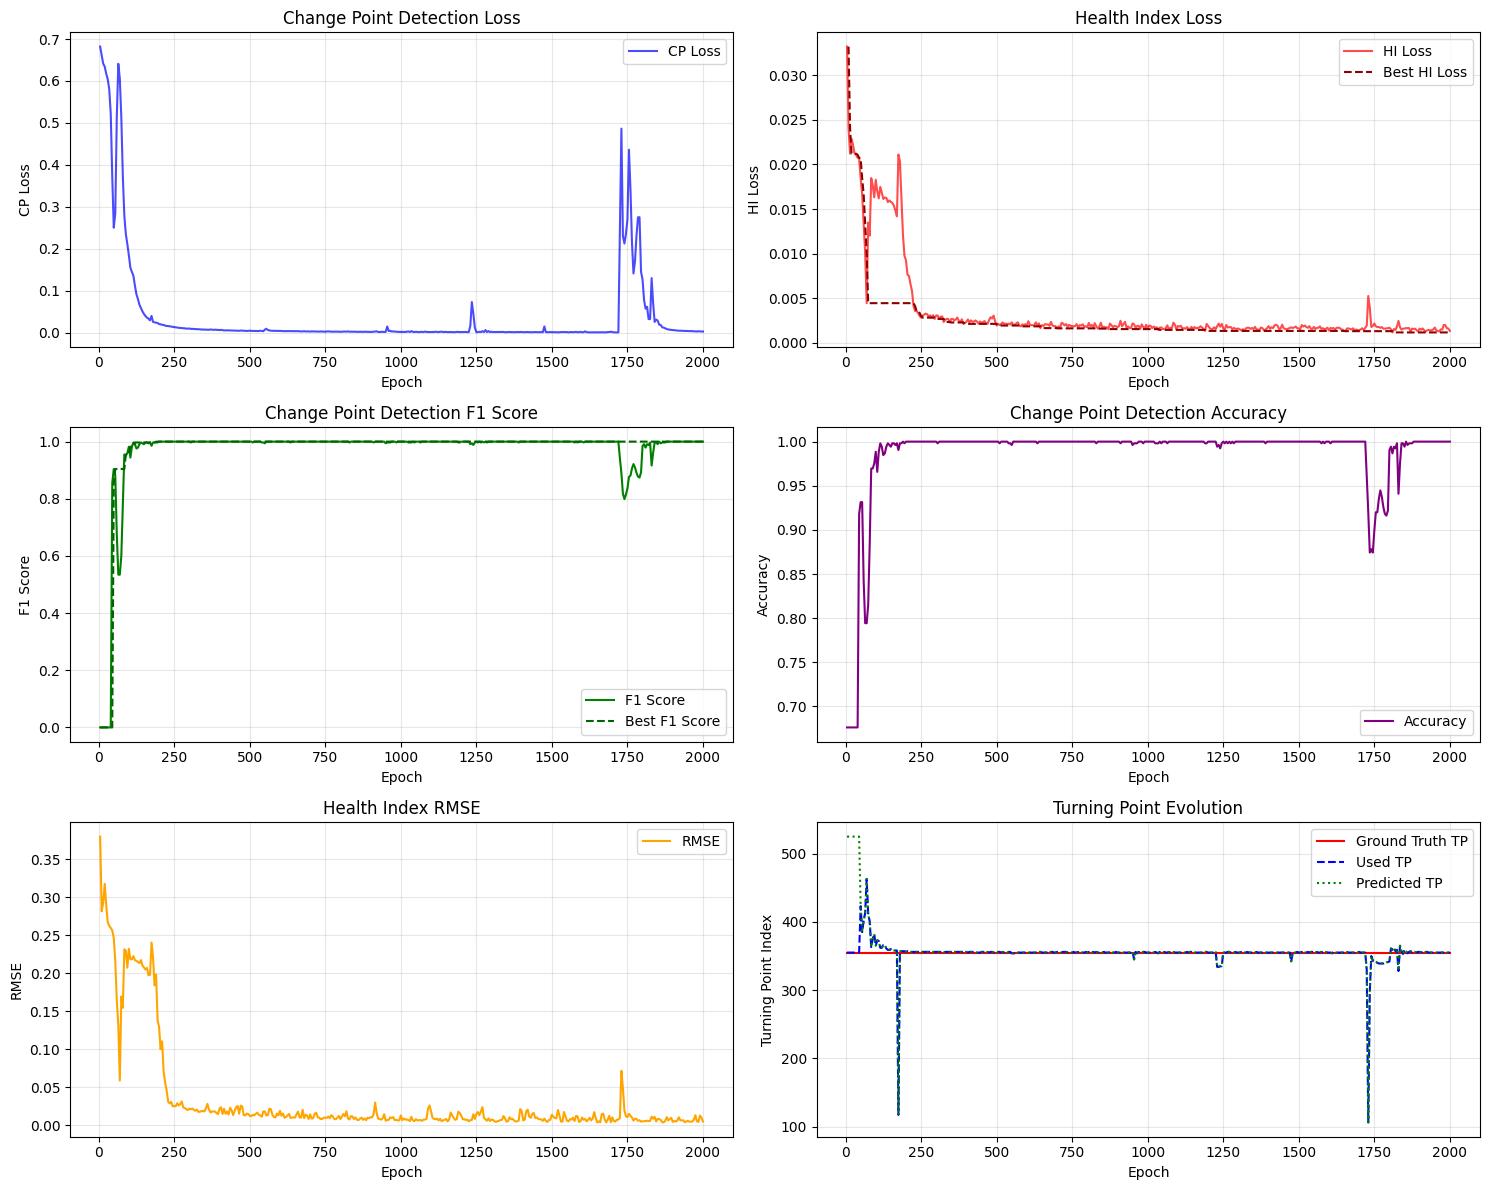


TRAINING SUMMARY
Total epochs trained: 400
Final CP Loss: 0.002996
Final HI Loss: 0.001341
Best CP F1 Score: 1.0000
Best HI Loss: 0.001177
Final CP F1 Score: 1.0000
Final CP Accuracy: 1.0000
Final HI RMSE: 0.0051
Final HI RPE: 4.16%


In [14]:
# Create comprehensive training visualization
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Plot 1: Loss curves
axes[0, 0].plot(training_log_df['epoch'], training_log_df['cp_loss'], label='CP Loss', color='blue', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('CP Loss')
axes[0, 0].set_title('Change Point Detection Loss')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(training_log_df['epoch'], training_log_df['hi_loss'], label='HI Loss', color='red', alpha=0.7)
axes[0, 1].plot(training_log_df['epoch'], training_log_df['best_hi_loss'], label='Best HI Loss', color='darkred', linestyle='--')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('HI Loss')
axes[0, 1].set_title('Health Index Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 2: CPD metrics
axes[1, 0].plot(training_log_df['epoch'], training_log_df['cp_f1'], label='F1 Score', color='green')
axes[1, 0].plot(training_log_df['epoch'], training_log_df['best_cp_f1'], label='Best F1 Score', color='darkgreen', linestyle='--')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Change Point Detection F1 Score')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(training_log_df['epoch'], training_log_df['cp_accuracy'], label='Accuracy', color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Change Point Detection Accuracy')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Plot 3: HI metrics and turning points
axes[2, 0].plot(training_log_df['epoch'], training_log_df['hi_rmse'], label='RMSE', color='orange')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('RMSE')
axes[2, 0].set_title('Health Index RMSE')
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].legend()

# Turning point evolution
axes[2, 1].plot(training_log_df['epoch'], training_log_df['turning_point_gt'], label='Ground Truth TP', color='red', linestyle='-')
axes[2, 1].plot(training_log_df['epoch'], training_log_df['turning_point_used'], label='Used TP', color='blue', linestyle='--')
axes[2, 1].plot(training_log_df['epoch'], training_log_df['turning_point_predicted'], label='Predicted TP', color='green', linestyle=':')
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('Turning Point Index')
axes[2, 1].set_title('Turning Point Evolution')
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].legend()

plt.tight_layout()
plt.show()

# Print training summary
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"Total epochs trained: {len(training_log_df)}")
print(f"Final CP Loss: {training_log_df['cp_loss'].iloc[-1]:.6f}")
print(f"Final HI Loss: {training_log_df['hi_loss'].iloc[-1]:.6f}")
print(f"Best CP F1 Score: {training_log_df['best_cp_f1'].max():.4f}")
print(f"Best HI Loss: {training_log_df['best_hi_loss'].min():.6f}")
print(f"Final CP F1 Score: {training_log_df['cp_f1'].iloc[-1]:.4f}")
print(f"Final CP Accuracy: {training_log_df['cp_accuracy'].iloc[-1]:.4f}")
print(f"Final HI RMSE: {training_log_df['hi_rmse'].iloc[-1]:.4f}")
print(f"Final HI RPE: {training_log_df['hi_rpe'].iloc[-1]:.2f}%")
print("="*60)

Main

Test turning point index: 354

--- Change Point Detection Evaluation Metrics ---
True turning point index: 354
Accuracy:  0.9981
Precision: 0.9942
Recall:    1.0000
F1-score:  0.9971
Confusion Matrix:
[[353   1]
 [  0 170]]
---------------------------------------


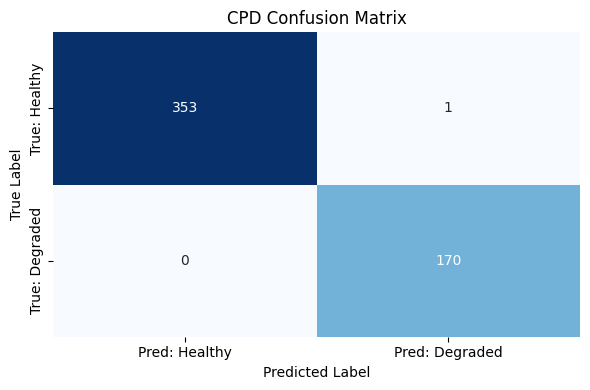


--- Health Index Evaluation Metrics (Degraded Region Only) ---
Samples in degraded region: 170
Mean Squared Error (MSE):      0.000026
Root Mean Squared Error (RMSE):  0.005132
Mean Absolute Error (MAE):       0.004055
R-squared (R²):                  0.999683
Relative Prediction Error (RPE): 6.94%
Asymmetric Loss:                0.000375
---------------------------------------


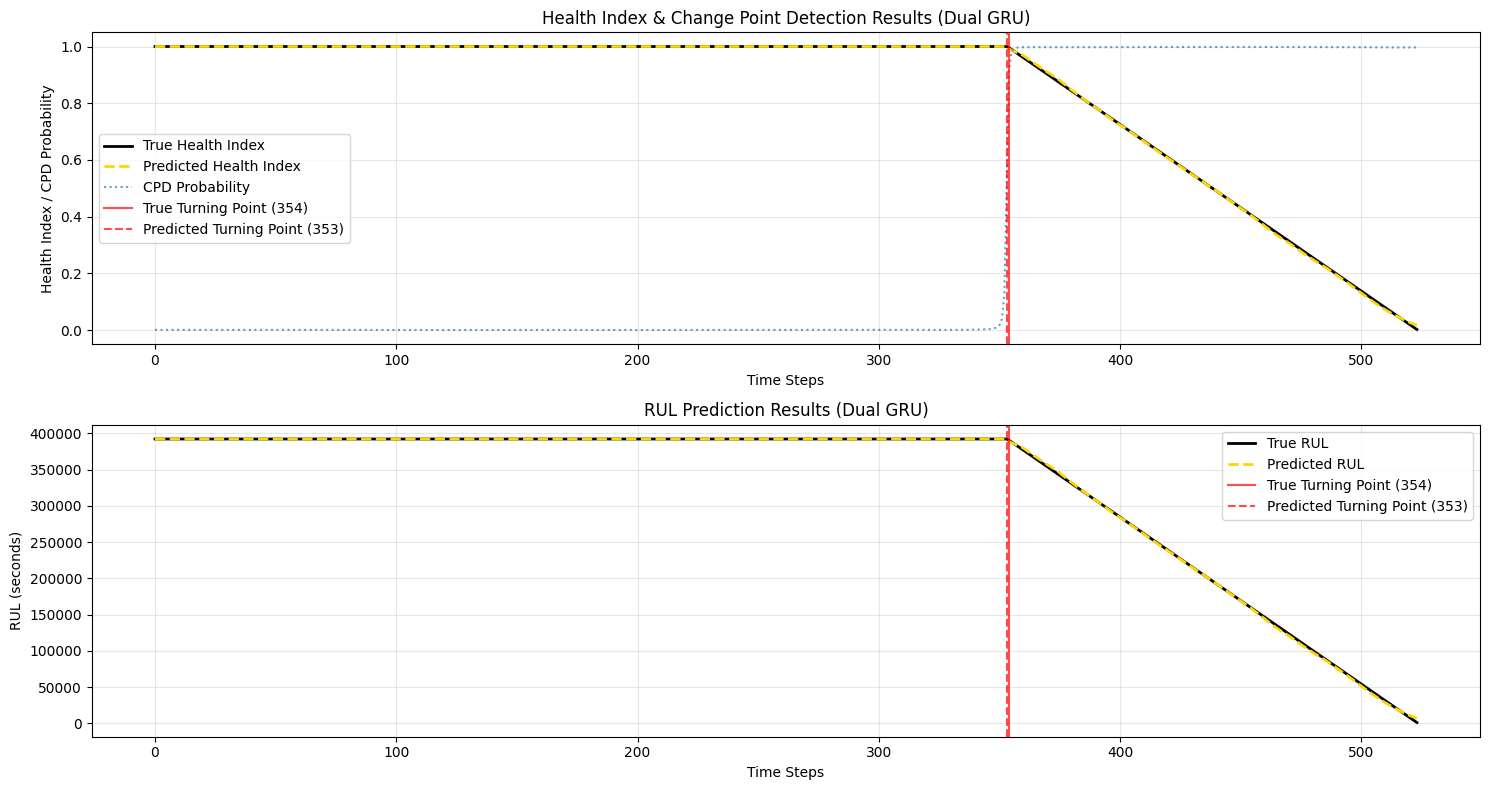


Results saved to: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_dual_gru_results.csv
Evaluation metrics saved to: /home/praktikan/projects/github/DwiAnggara/ProyekRisetBearing/bearing_1/datasets/fft_dual_gru_eval_metrics.csv


In [15]:
# --- EVALUATION ---
cp_model.eval()
hi_model.eval()

# Find test turning point
test_turning_point_idx = np.argmax(y_test_seq < 1.0) if np.any(y_test_seq < 1.0) else len(y_test_seq)
print(f"Test turning point index: {test_turning_point_idx}")

with torch.no_grad():
    # --- CPD Evaluation ---
    test_cp_pred_tensor = cp_model(X_test_tensor)
    test_cp_pred_prob = test_cp_pred_tensor.cpu().numpy().flatten()

    test_cp_pred = (test_cp_pred_prob > 0.5).astype(int)

    # CPD ground truth: 0 before turning point, 1 after turning point
    y_cp_test_binary = np.zeros(len(y_test_seq))
    if test_turning_point_idx < len(y_test_seq):
        y_cp_test_binary[test_turning_point_idx:] = 1

    # CPD metrics
    cp_accuracy = accuracy_score(y_cp_test_binary, test_cp_pred)
    cp_precision = precision_score(y_cp_test_binary, test_cp_pred)
    cp_recall = recall_score(y_cp_test_binary, test_cp_pred)
    cp_f1 = f1_score(y_cp_test_binary, test_cp_pred)
    cp_cm = confusion_matrix(y_cp_test_binary, test_cp_pred)


print("\n--- Change Point Detection Evaluation Metrics ---")
print(f"True turning point index: {test_turning_point_idx}")
print(f"Accuracy:  {cp_accuracy:.4f}")
print(f"Precision: {cp_precision:.4f}")
print(f"Recall:    {cp_recall:.4f}")
print(f"F1-score:  {cp_f1:.4f}")
print("Confusion Matrix:")
print(cp_cm)
print("---------------------------------------")

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cp_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Healthy", "Pred: Degraded"], 
            yticklabels=["True: Healthy", "True: Degraded"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CPD Confusion Matrix")
plt.tight_layout()
plt.show()

# --- HI Evaluation (only on degraded samples) ---
with torch.no_grad():
    if test_turning_point_idx < len(y_test_seq):
        X_test_degraded = X_test_tensor[test_turning_point_idx:]
        y_test_degraded = y_test_tensor[test_turning_point_idx:]
        
        if len(X_test_degraded) > 0:
            test_hi_pred_tensor = hi_model(X_test_degraded)
            test_hi_pred_degraded = test_hi_pred_tensor.cpu().numpy().flatten()
            y_hi_true_degraded = y_test_degraded.cpu().numpy().flatten()
            
            # HI metrics (only degraded region)
            mse_degraded = mean_squared_error(y_hi_true_degraded, test_hi_pred_degraded)
            rmse_degraded = rmse_score(y_hi_true_degraded, test_hi_pred_degraded)
            mae_degraded = mean_absolute_error(y_hi_true_degraded, test_hi_pred_degraded)
            r2_degraded = r2_score(y_hi_true_degraded, test_hi_pred_degraded)
            rpe_degraded = relative_prediction_error(y_hi_true_degraded, test_hi_pred_degraded)

            # Asymmetric loss (PyTorch, degraded region)
            asym_loss_degraded = asymmetric_loss_scoring_function(
                test_hi_pred_tensor, y_test_degraded
            ).item()
        else:
            mse_degraded = rmse_degraded = mae_degraded = r2_degraded = rpe_degraded = 0.0
            asym_loss_degraded = 0.0
            test_hi_pred_degraded = np.array([])
    else:
        mse_degraded = rmse_degraded = mae_degraded = r2_degraded = rpe_degraded = 0.0
        asym_loss_degraded = 0.0
        test_hi_pred_degraded = np.array([])

print("\n--- Health Index Evaluation Metrics (Degraded Region Only) ---")
print(f"Samples in degraded region: {len(test_hi_pred_degraded) if len(test_hi_pred_degraded) > 0 else 0}")
print(f"Mean Squared Error (MSE):      {mse_degraded:.6f}")
print(f"Root Mean Squared Error (RMSE):  {rmse_degraded:.6f}")
print(f"Mean Absolute Error (MAE):       {mae_degraded:.6f}")
print(f"R-squared (R²):                  {r2_degraded:.6f}")
print(f"Relative Prediction Error (RPE): {rpe_degraded:.2f}%")
print(f"Asymmetric Loss:                {asym_loss_degraded:.6f}")
print("---------------------------------------")

# Create full predictions for visualization
# Use CPD model to determine predicted turning point
predicted_turning_point_idx = np.argmax(test_cp_pred_prob > 0.5) if np.any(test_cp_pred_prob > 0.5) else len(y_test_seq)

# Construct full HI prediction: 1.0 before predicted turning point, model output after
test_hi_pred_full = np.ones(len(y_test_seq))
if predicted_turning_point_idx < len(y_test_seq) and len(test_hi_pred_degraded) > 0:
    # Adjust indices to match the degraded region
    remaining_samples = len(y_test_seq) - test_turning_point_idx
    pred_samples = min(len(test_hi_pred_degraded), remaining_samples)
    test_hi_pred_full[test_turning_point_idx:test_turning_point_idx + pred_samples] = test_hi_pred_degraded[:pred_samples]

# Visualization
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(y_test_seq, label='True Health Index', linewidth=2, **PLOT_STYLES["HI"])
plt.plot(test_hi_pred_full, label='Predicted Health Index', **PLOT_STYLES["HI_PRED"], linewidth=2)
plt.plot(test_cp_pred_prob, label='CPD Probability', linestyle=':', alpha=0.7)
plt.axvline(x=test_turning_point_idx, **PLOT_STYLES["TP"], alpha=0.7, label=f'True Turning Point ({test_turning_point_idx})')
plt.axvline(x=predicted_turning_point_idx, **PLOT_STYLES["TP_PRED"], alpha=0.7, label=f'Predicted Turning Point ({predicted_turning_point_idx})')
plt.title('Health Index & Change Point Detection Results (Dual GRU)')
plt.xlabel('Time Steps')
plt.ylabel('Health Index / CPD Probability')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(health_index_to_rul(y_test_seq, BEARING_LIFESPAN_TIME), label='True RUL', linewidth=2, **PLOT_STYLES["HI"])
plt.plot(health_index_to_rul(test_hi_pred_full, BEARING_LIFESPAN_TIME), label='Predicted RUL', **PLOT_STYLES["HI_PRED"], linewidth=2)
plt.axvline(x=test_turning_point_idx, **PLOT_STYLES["TP"], alpha=0.7, label=f'True Turning Point ({test_turning_point_idx})')
plt.axvline(x=predicted_turning_point_idx, **PLOT_STYLES["TP_PRED"], alpha=0.7, label=f'Predicted Turning Point ({predicted_turning_point_idx})')
plt.title('RUL Prediction Results (Dual GRU)')
plt.xlabel('Time Steps')
plt.ylabel('RUL (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Export results
results_df = pd.DataFrame({
    'time_step': np.arange(len(y_test_seq)),
    'true_health_index': y_test_seq,
    'predicted_health_index': test_hi_pred_full,
    'cpd_probability': test_cp_pred_prob,
    'cpd_binary': test_cp_pred,
    'true_cpd_binary': y_cp_test_binary,
    'predicted_rul': health_index_to_rul(test_hi_pred_full, BEARING_LIFESPAN_TIME),
})
results_path = f"{_func(MAIN_BEARING)}_dual_gru_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")

# Export evaluation metrics
eval_metrics_df = pd.DataFrame([{
    'model': 'dual_gru',
    'turning_point_true_idx': test_turning_point_idx,
    'turning_point_pred_idx': predicted_turning_point_idx,
    'cp_accuracy': cp_accuracy,
    'cp_precision': cp_precision,
    'cp_recall': cp_recall,
    'cp_f1': cp_f1,
    'samples_degraded': len(test_hi_pred_degraded) if len(test_hi_pred_degraded) > 0 else 0,
    'hi_mse_degraded': mse_degraded,
    'hi_rmse_degraded': rmse_degraded,
    'hi_mae_degraded': mae_degraded,
    'hi_r2_degraded': r2_degraded,
    'hi_rpe_degraded': rpe_degraded,
    'hi_asymmetric_loss_degraded': asym_loss_degraded
}])
eval_metrics_path = f"{_func(MAIN_BEARING)}_dual_gru_eval_metrics.csv"
eval_metrics_df.to_csv(eval_metrics_path, index=False)
print(f"Evaluation metrics saved to: {eval_metrics_path}")